# Decoding Customer Value: A SQL-Driven Retention Strategy

## Customer Intelligence Engine

### Team
- Akshit Sukhija → Product Intelligence & Strategic Analytics
- Bhumika → Analytics Validation & Visualization

### Objective
Build a customer intelligence system capable of identifying:
- loyal customers
- promo-dependent customers
- retention opportunities
- high-value behavioral patterns
- customer segments for strategic decision-making

### Current Phase
Phase 1 → Data Audit & Business Understanding

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [4]:
# Load Dataset
df = pd.read_csv('/content/customer_intelligence_dataset.csv')

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


# Step 1A — Initial Dataset Inspection

Goal:
Understand dataset structure before any transformation.

Focus Areas:
- dataset shape
- column understanding
- sample records
- business context clues

In [5]:
# Dataset Shape
print("Dataset Shape:")
print(df.shape)

print("\n")

# Column Names
print("Columns:")
print(df.columns.tolist())

Dataset Shape:
(3900, 18)


Columns:
['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season', 'Review Rating', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Previous Purchases', 'Payment Method', 'Frequency of Purchases']


In [6]:
# First 10 Rows
df.head(10)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually
5,6,46,Male,Sneakers,Footwear,20,Wyoming,M,White,Summer,2.9,Yes,Standard,Yes,Yes,14,Venmo,Weekly
6,7,63,Male,Shirt,Clothing,85,Montana,M,Gray,Fall,3.2,Yes,Free Shipping,Yes,Yes,49,Cash,Quarterly
7,8,27,Male,Shorts,Clothing,34,Louisiana,L,Charcoal,Winter,3.2,Yes,Free Shipping,Yes,Yes,19,Credit Card,Weekly
8,9,26,Male,Coat,Outerwear,97,West Virginia,L,Silver,Summer,2.6,Yes,Express,Yes,Yes,8,Venmo,Annually
9,10,57,Male,Handbag,Accessories,31,Missouri,M,Pink,Spring,4.8,Yes,2-Day Shipping,Yes,Yes,4,Cash,Quarterly


In [7]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [8]:
# Statistical Summary
df.describe(include='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


# Step 1B — Data Quality Audit

Objective:
Identify:
- missing values
- duplicate rows
- inconsistent fields
- suspicious columns
- potential business risks

In [9]:
# Missing Values
nulls = df.isnull().sum().sort_values(ascending=False)

nulls[nulls > 0]

,0
Review Rating,37


In [10]:
# Duplicate Records
duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


In [11]:
# Unique Values Per Column
df.nunique().sort_values()

,0
Gender,2
Promo Code Used,2
Discount Applied,2
Subscription Status,2
Season,4
Category,4
Size,4
Shipping Type,6
Payment Method,6
Frequency of Purchases,7


# Step 1C — Column Classification

Goal:
Map columns into business-relevant analytical groups.

These classifications will guide:
- feature engineering
- SQL segmentation
- dashboard design
- retention analysis

In [12]:
# Display All Dataset Columns

print("Total Columns:", len(df.columns))
print("\nDataset Columns:\n")

for col in df.columns:
    print(col)

Total Columns: 18

Dataset Columns:

Customer ID
Age
Gender
Item Purchased
Category
Purchase Amount (USD)
Location
Size
Color
Season
Review Rating
Subscription Status
Shipping Type
Discount Applied
Promo Code Used
Previous Purchases
Payment Method
Frequency of Purchases


In [13]:
column_classification = {

    "Customer Attributes": [
        "Customer ID",
        "Age",
        "Gender",
        "Subscription Status"
    ],

    "Transaction Metrics": [
        "Purchase Amount (USD)",
        "Review Rating",
        "Previous Purchases"
    ],

    "Promotional Variables": [
        "Discount Applied",
        "Promo Code Used"
    ],

    "Product Variables": [
        "Item Purchased",
        "Category",
        "Size",
        "Color",
        "Season"
    ],

    "Geography Variables": [
        "Location"
    ],

    "Behavioral Signals": [
        "Frequency of Purchases"
    ],

    "Operational Fields": [
        "Shipping Type",
        "Payment Method"
    ]

}

column_classification

{'Customer Attributes': ['Customer ID',
  'Age',
  'Gender',
  'Subscription Status'],
 'Transaction Metrics': ['Purchase Amount (USD)',
  'Review Rating',
  'Previous Purchases'],
 'Promotional Variables': ['Discount Applied', 'Promo Code Used'],
 'Product Variables': ['Item Purchased',
  'Category',
  'Size',
  'Color',
  'Season'],
 'Geography Variables': ['Location'],
 'Behavioral Signals': ['Frequency of Purchases'],
 'Operational Fields': ['Shipping Type', 'Payment Method']}

# Initial Strategic Observations

## Potential Loyalty Signals
- Customers with higher previous purchase counts may indicate stronger repeat behavior.
- Subscription-based customers may demonstrate stronger retention potential.
- Higher purchase frequency may correlate with long-term customer value.
- Customers purchasing across multiple categories may represent broader engagement.

## Potential Promo Dependency Signals
- Customers consistently using discounts and promo codes may indicate price-sensitive behavior.
- High purchase activity combined with frequent discount usage may reduce true profitability.
- Certain product categories may rely more heavily on promotions for conversion.

## Potential Retention Indicators
- Repeat purchases combined with stable review ratings may indicate satisfaction-driven retention.
- Subscription status may act as a proxy for brand affinity.
- Frequency of purchases may help identify high-engagement customer segments.

## Risks & Concerns
- Dataset does not contain timestamps, limiting lifecycle and cohort analysis.
- No direct churn label exists, so loyalty must be behaviorally inferred.
- Limited demographic depth may weaken ideal customer profile precision.
- Operational fields may provide weaker strategic value compared to behavioral metrics.

In [14]:
# Strategic Reflection Notes

strategic_notes = [
    "The dataset structure is highly suitable for customer segmentation and retention analysis.",

    "Behavioral loyalty will likely need to be inferred using purchase frequency, previous purchases, and promo dependency patterns.",

    "Promotional variables may reveal which customer segments are margin-destructive versus organically loyal.",

    "Subscription status may become one of the strongest indicators of retention quality.",

    "Future engineered features should prioritize commercially actionable customer intelligence instead of vanity analytics."
]

for note in strategic_notes:
    print("•", note)

• The dataset structure is highly suitable for customer segmentation and retention analysis.
• Behavioral loyalty will likely need to be inferred using purchase frequency, previous purchases, and promo dependency patterns.
• Promotional variables may reveal which customer segments are margin-destructive versus organically loyal.
• Subscription status may become one of the strongest indicators of retention quality.
• Future engineered features should prioritize commercially actionable customer intelligence instead of vanity analytics.


# Step 2 — Customer Feature Engineering

## Objective
Transform raw transactional and behavioral data into commercially meaningful customer intelligence metrics.

These engineered features will help:
- identify loyal customers
- detect promo dependency
- understand customer quality
- support segmentation logic
- guide retention strategy decisions

Focus:
Business usefulness over technical complexity.

In [15]:
# Planned Engineered Features

feature_roadmap = pd.DataFrame({

    "Feature": [
        "Promo_Dependency_Score",
        "Purchase_Frequency_Score",
        "Customer_Value_Tier",
        "Category_Diversity",
        "Average_Order_Value",
        "Review_Engagement_Score",
        "Loyalty_Score_A",
        "Loyalty_Score_B"
    ],

    "Business Purpose": [
        "Detect discount-reliant customers",
        "Measure repeat purchasing intensity",
        "Classify customer commercial value",
        "Measure breadth of customer engagement",
        "Understand spending quality",
        "Estimate satisfaction and engagement",
        "Behavioral loyalty measurement",
        "Commercial loyalty measurement"
    ],

    "Strategic Decision Enabled": [
        "Reduce unnecessary promotions",
        "Identify retention-worthy customers",
        "Prioritize high-value segments",
        "Design cross-sell strategies",
        "Identify premium customer groups",
        "Detect customer satisfaction quality",
        "Detect organically loyal customers",
        "Detect revenue-driving customers"
    ]

})

feature_roadmap

,Feature,Business Purpose,Strategic Decision Enabled
0,Promo_Dependency_Score,Detect discount-reliant customers,Reduce unnecessary promotions
1,Purchase_Frequency_Score,Measure repeat purchasing intensity,Identify retention-worthy customers
2,Customer_Value_Tier,Classify customer commercial value,Prioritize high-value segments
3,Category_Diversity,Measure breadth of customer engagement,Design cross-sell strategies
4,Average_Order_Value,Understand spending quality,Identify premium customer groups
5,Review_Engagement_Score,Estimate satisfaction and engagement,Detect customer satisfaction quality
6,Loyalty_Score_A,Behavioral loyalty measurement,Detect organically loyal customers
7,Loyalty_Score_B,Commercial loyalty measurement,Detect revenue-driving customers


## Feature 1 — Promo Dependency Score

### Business Meaning
Measures how dependent a customer is on discounts and promo codes while purchasing.

### Strategic Importance
Helps identify:
- margin-destructive customer segments
- organically loyal customers
- customers who only purchase during promotions

### Founder Decision Enabled
Should the company continue discounting this customer segment?

In [16]:
# Promo Dependency Score

df["Discount Applied"] = df["Discount Applied"].map({
    "Yes": 1,
    "No": 0
})

df["Promo Code Used"] = df["Promo Code Used"].map({
    "Yes": 1,
    "No": 0
})

df["Promo_Dependency_Score"] = (
    df["Discount Applied"] +
    df["Promo Code Used"]
) / 2

df[[
    "Customer ID",
    "Discount Applied",
    "Promo Code Used",
    "Promo_Dependency_Score"
]].head()

,Customer ID,Discount Applied,Promo Code Used,Promo_Dependency_Score
0,1,1,1,1.0
1,2,1,1,1.0
2,3,1,1,1.0
3,4,1,1,1.0
4,5,1,1,1.0


## Feature 2 — Customer Value Tier

### Business Meaning
Segments customers based on commercial spending contribution.

### Strategic Importance
Helps identify:
- premium customers
- mid-value customers
- low-value customers

### Founder Decision Enabled
Which customers deserve higher retention investment?

In [17]:
# Customer Value Tier

df["Customer_Value_Tier"] = pd.qcut(
    df["Purchase Amount (USD)"],
    q=3,
    labels=["Low Value", "Mid Value", "High Value"]
)

df[[
    "Customer ID",
    "Purchase Amount (USD)",
    "Customer_Value_Tier"
]].head()

,Customer ID,Purchase Amount (USD),Customer_Value_Tier
0,1,53,Mid Value
1,2,64,Mid Value
2,3,73,Mid Value
3,4,90,High Value
4,5,49,Mid Value


## Feature 3 — Review Engagement Score

### Business Meaning
Uses customer ratings as a lightweight proxy for satisfaction and engagement.

### Strategic Importance
Helps estimate:
- customer satisfaction quality
- potential retention strength
- positive customer sentiment

### Founder Decision Enabled
Which customer groups may require retention attention?

In [18]:
# Review Engagement Score

df["Review_Engagement_Score"] = (
    df["Review Rating"] / 5
)

df[[
    "Customer ID",
    "Review Rating",
    "Review_Engagement_Score"
]].head()

,Customer ID,Review Rating,Review_Engagement_Score
0,1,3.1,0.62
1,2,3.1,0.62
2,3,3.1,0.62
3,4,3.5,0.70
4,5,2.7,0.54


## Feature 4 — Purchase Frequency Score

### Business Meaning
Measures how actively customers engage in repeat purchasing.

### Strategic Importance
Helps identify:
- high-engagement customers
- retention-worthy segments
- loyalty potential

### Founder Decision Enabled
Which customer groups are most likely to continue purchasing?

In [20]:
# Purchase Frequency Score

max_purchases = df["Previous Purchases"].max()

df["Purchase_Frequency_Score"] = (
    df["Previous Purchases"] / max_purchases
)

df[[
    "Customer ID",
    "Previous Purchases",
    "Purchase_Frequency_Score"
]].head()

,Customer ID,Previous Purchases,Purchase_Frequency_Score
0,1,14,0.28
1,2,2,0.04
2,3,23,0.46
3,4,49,0.98
4,5,31,0.62


# Step 3 — Loyalty Intelligence Framework Design

## Objective
Design multiple loyalty frameworks to avoid simplistic customer evaluation logic.

The project intentionally does not provide:
- loyalty labels
- churn labels
- retention definitions

Therefore, loyalty must be behaviorally inferred using transactional and engagement signals.

This phase focuses on:
- behavioral loyalty
- commercial loyalty
- retention-oriented customer quality
- promo dependency tradeoffs

Goal:
Build founder-meaningful customer intelligence instead of shallow analytics.

## Loyalty Framework A — Behavioral Loyalty

### Philosophy
A truly loyal customer:
- purchases consistently
- is less dependent on promotions
- demonstrates stronger engagement behavior

### Signals Used
- Purchase Frequency Score
- Review Engagement Score
- Promo Dependency Score

### Strategic Value
Helps identify:
- organically loyal customers
- retention-stable customer groups
- lower-margin-risk segments

In [21]:
# Loyalty Score A — Behavioral Loyalty

df["Loyalty_Score_A"] = (
    (df["Purchase_Frequency_Score"] * 0.4) +
    (df["Review_Engagement_Score"] * 0.4) +
    ((1 - df["Promo_Dependency_Score"]) * 0.2)
)

df[[
    "Customer ID",
    "Purchase_Frequency_Score",
    "Review_Engagement_Score",
    "Promo_Dependency_Score",
    "Loyalty_Score_A"
]].head()

,Customer ID,Purchase_Frequency_Score,Review_Engagement_Score,Promo_Dependency_Score,Loyalty_Score_A
0,1,0.28,0.62,1.0,0.360
1,2,0.04,0.62,1.0,0.264
2,3,0.46,0.62,1.0,0.432
3,4,0.98,0.70,1.0,0.672
4,5,0.62,0.54,1.0,0.464


## Loyalty Framework B — Commercial Loyalty

### Philosophy
Commercially valuable customers are those who contribute stronger revenue and purchasing value.

This framework prioritizes:
- customer spending
- purchasing intensity
- commercial contribution

### Signals Used
- Purchase Amount
- Previous Purchases
- Customer Value Tier

### Strategic Value
Helps identify:
- revenue-driving customers
- premium customer groups
- high-LTV opportunities

In [22]:
# Normalize Purchase Amount

df["Normalized_Purchase_Amount"] = (
    df["Purchase Amount (USD)"] /
    df["Purchase Amount (USD)"].max()
)

# Normalize Previous Purchases

df["Normalized_Previous_Purchases"] = (
    df["Previous Purchases"] /
    df["Previous Purchases"].max()
)

# Loyalty Score B — Commercial Loyalty

df["Loyalty_Score_B"] = (
    (df["Normalized_Purchase_Amount"] * 0.5) +
    (df["Normalized_Previous_Purchases"] * 0.5)
)

df[[
    "Customer ID",
    "Normalized_Purchase_Amount",
    "Normalized_Previous_Purchases",
    "Loyalty_Score_B"
]].head()

,Customer ID,Normalized_Purchase_Amount,Normalized_Previous_Purchases,Loyalty_Score_B
0,1,0.53,0.28,0.405
1,2,0.64,0.04,0.340
2,3,0.73,0.46,0.595
3,4,0.90,0.98,0.940
4,5,0.49,0.62,0.555


## Comparing Loyalty Frameworks

### Key Analytical Question
Does high spending automatically imply genuine loyalty?

This comparison helps distinguish:
- organically loyal customers
vs
- commercially valuable but promotion-driven customers

The goal is to avoid simplistic assumptions while building customer intelligence.

In [23]:
# Compare Loyalty Scores

df[[
    "Customer ID",
    "Loyalty_Score_A",
    "Loyalty_Score_B"
]].head(10)

,Customer ID,Loyalty_Score_A,Loyalty_Score_B
0,1,0.360,0.405
1,2,0.264,0.340
2,3,0.432,0.595
3,4,0.672,0.940
4,5,0.464,0.555
5,6,0.344,0.240
6,7,0.648,0.915
7,8,0.408,0.360
8,9,0.272,0.565
9,10,0.416,0.195


## Loyalty-Based Customer Labeling

Goal:
Translate numerical loyalty scores into founder-friendly customer intelligence categories.

In [24]:
# Loyalty Segment Labels

conditions = [
    (df["Loyalty_Score_A"] >= 0.7) & (df["Loyalty_Score_B"] >= 0.7),

    (df["Loyalty_Score_A"] >= 0.7) & (df["Loyalty_Score_B"] < 0.7),

    (df["Loyalty_Score_A"] < 0.7) & (df["Loyalty_Score_B"] >= 0.7),

    (df["Loyalty_Score_A"] < 0.7) & (df["Loyalty_Score_B"] < 0.7)
]

labels = [
    "Premium Loyalists",
    "Emotionally Loyal",
    "Revenue-Driven Buyers",
    "At-Risk Customers"
]

df["Customer_Loyalty_Segment"] = np.select(
    conditions,
    labels,
    default="Unclassified"
)

df[[
    "Customer ID",
    "Loyalty_Score_A",
    "Loyalty_Score_B",
    "Customer_Loyalty_Segment"
]].head(15)

,Customer ID,Loyalty_Score_A,Loyalty_Score_B,Customer_Loyalty_Segment
0,1,0.360,0.405,At-Risk Customers
1,2,0.264,0.340,At-Risk Customers
2,3,0.432,0.595,At-Risk Customers
3,4,0.672,0.940,Revenue-Driven Buyers
4,5,0.464,0.555,At-Risk Customers
5,6,0.344,0.240,At-Risk Customers
6,7,0.648,0.915,Revenue-Driven Buyers
7,8,0.408,0.360,At-Risk Customers
8,9,0.272,0.565,At-Risk Customers
9,10,0.416,0.195,At-Risk Customers


In [25]:
# Strategic Interpretation Notes

loyalty_insights = [
    "High-spending customers are not always genuinely loyal.",

    "Behavioral loyalty and commercial loyalty may diverge significantly.",

    "Promo dependency may artificially inflate perceived customer value.",

    "Founder retention strategies should differentiate between emotional loyalty and revenue contribution.",

    "The strongest long-term customer segments are likely those with high engagement and low discount dependency."
]

for insight in loyalty_insights:
    print("•", insight)

• High-spending customers are not always genuinely loyal.
• Behavioral loyalty and commercial loyalty may diverge significantly.
• Promo dependency may artificially inflate perceived customer value.
• Founder retention strategies should differentiate between emotional loyalty and revenue contribution.
• The strongest long-term customer segments are likely those with high engagement and low discount dependency.


# Step 4 — Strategic Customer Segmentation

## Objective
Translate customer metrics and loyalty signals into commercially meaningful customer intelligence segments.

These segments will help:
- identify high-retention customers
- detect margin-risk customers
- improve targeting strategy
- support founder-level decision-making
- prioritize retention investments

Focus:
Business usefulness over algorithmic complexity.

In [26]:
# Strategic Segmentation Framework

segmentation_framework = pd.DataFrame({

    "Segment": [
        "Premium Loyalists",
        "Emotionally Loyal Customers",
        "Revenue-Driven Buyers",
        "Discount Survivors",
        "At-Risk Customers"
    ],

    "Core Behavior": [
        "High loyalty + high commercial value",
        "High engagement but moderate spending",
        "Strong spending but weaker behavioral loyalty",
        "High promo dependency",
        "Low loyalty + low engagement"
    ],

    "Strategic Risk": [
        "Low",
        "Medium",
        "Medium",
        "High",
        "Very High"
    ],

    "Founder Priority": [
        "Retention & VIP nurturing",
        "Upsell & engagement expansion",
        "Margin optimization",
        "Reduce promo dependency",
        "Reactivation or deprioritization"
    ]

})

segmentation_framework

,Segment,Core Behavior,Strategic Risk,Founder Priority
0,Premium Loyalists,High loyalty + high commercial value,Low,Retention & VIP nurturing
1,Emotionally Loyal Customers,High engagement but moderate spending,Medium,Upsell & engagement expansion
2,Revenue-Driven Buyers,Strong spending but weaker behavioral loyalty,Medium,Margin optimization
3,Discount Survivors,High promo dependency,High,Reduce promo dependency
4,At-Risk Customers,Low loyalty + low engagement,Very High,Reactivation or deprioritization


## Promo Dependency Segmentation

### Objective
Identify customers whose purchasing behavior is heavily influenced by discounts and promotional incentives.

### Strategic Importance
Excessive promotional dependency may:
- reduce profitability
- weaken genuine loyalty
- inflate perceived customer value
- create retention instability

In [27]:
# Promo Dependency Segments

conditions = [
    (df["Promo_Dependency_Score"] >= 0.75),

    (df["Promo_Dependency_Score"] >= 0.40) &
    (df["Promo_Dependency_Score"] < 0.75),

    (df["Promo_Dependency_Score"] < 0.40)
]

labels = [
    "Highly Promo Dependent",
    "Moderately Promo Influenced",
    "Organically Motivated"
]

df["Promo_Dependency_Segment"] = np.select(
    conditions,
    labels,
    default="Unclassified"
)

df[[
    "Customer ID",
    "Promo_Dependency_Score",
    "Promo_Dependency_Segment"
]].head(15)

,Customer ID,Promo_Dependency_Score,Promo_Dependency_Segment
0,1,1.0,Highly Promo Dependent
1,2,1.0,Highly Promo Dependent
2,3,1.0,Highly Promo Dependent
3,4,1.0,Highly Promo Dependent
4,5,1.0,Highly Promo Dependent
5,6,1.0,Highly Promo Dependent
6,7,1.0,Highly Promo Dependent
7,8,1.0,Highly Promo Dependent
8,9,1.0,Highly Promo Dependent
9,10,1.0,Highly Promo Dependent


## Customer Engagement Segmentation

### Objective
Identify how actively customers engage with the brand through purchasing frequency and behavioral interaction.

### Strategic Importance
Helps identify:
- highly engaged customers
- passive customers
- retention opportunities
- engagement risk groups

In [28]:
# Engagement Segments

conditions = [
    (df["Purchase_Frequency_Score"] >= 0.70),

    (df["Purchase_Frequency_Score"] >= 0.40) &
    (df["Purchase_Frequency_Score"] < 0.70),

    (df["Purchase_Frequency_Score"] < 0.40)
]

labels = [
    "Highly Engaged",
    "Moderately Engaged",
    "Low Engagement"
]

df["Customer_Engagement_Segment"] = np.select(
    conditions,
    labels,
    default="Unclassified"
)

df[[
    "Customer ID",
    "Purchase_Frequency_Score",
    "Customer_Engagement_Segment"
]].head(15)

,Customer ID,Purchase_Frequency_Score,Customer_Engagement_Segment
0,1,0.28,Low Engagement
1,2,0.04,Low Engagement
2,3,0.46,Moderately Engaged
3,4,0.98,Highly Engaged
4,5,0.62,Moderately Engaged
5,6,0.28,Low Engagement
6,7,0.98,Highly Engaged
7,8,0.38,Low Engagement
8,9,0.16,Low Engagement
9,10,0.08,Low Engagement


## Master Customer Intelligence Segmentation

### Objective
Combine loyalty, engagement, and promotional behavior into a unified customer intelligence framework.

### Strategic Goal
Enable founder-level customer prioritization and retention strategy decisions.

In [29]:
# Master Customer Segmentation

conditions = [

    # Premium Loyalists
    (
        (df["Loyalty_Score_A"] >= 0.70) &
        (df["Promo_Dependency_Score"] < 0.40)
    ),

    # Revenue-Driven Buyers
    (
        (df["Loyalty_Score_B"] >= 0.70) &
        (df["Promo_Dependency_Score"] >= 0.40)
    ),

    # Emotionally Loyal
    (
        (df["Loyalty_Score_A"] >= 0.70) &
        (df["Loyalty_Score_B"] < 0.70)
    ),

    # Discount Survivors
    (
        (df["Promo_Dependency_Score"] >= 0.75)
    ),

    # At-Risk Customers
    (
        (df["Loyalty_Score_A"] < 0.40) &
        (df["Purchase_Frequency_Score"] < 0.40)
    )
]

labels = [
    "Premium Loyalists",
    "Revenue-Driven Buyers",
    "Emotionally Loyal",
    "Discount Survivors",
    "At-Risk Customers"
]

df["Master_Customer_Segment"] = np.select(
    conditions,
    labels,
    default="Moderate Customers"
)

df[[
    "Customer ID",
    "Loyalty_Score_A",
    "Loyalty_Score_B",
    "Promo_Dependency_Score",
    "Master_Customer_Segment"
]].head(20)

,Customer ID,Loyalty_Score_A,Loyalty_Score_B,Promo_Dependency_Score,Master_Customer_Segment
0,1,0.360,0.405,1.0,Discount Survivors
1,2,0.264,0.340,1.0,Discount Survivors
2,3,0.432,0.595,1.0,Discount Survivors
3,4,0.672,0.940,1.0,Revenue-Driven Buyers
4,5,0.464,0.555,1.0,Discount Survivors
5,6,0.344,0.240,1.0,Discount Survivors
6,7,0.648,0.915,1.0,Revenue-Driven Buyers
7,8,0.408,0.360,1.0,Discount Survivors
8,9,0.272,0.565,1.0,Discount Survivors
9,10,0.416,0.195,1.0,Discount Survivors


## Segment Distribution Analysis

### Objective
Understand how customers are distributed across strategic customer intelligence groups.

### Strategic Importance
Helps evaluate:
- customer quality mix
- retention concentration
- promo dependency risk
- potential growth opportunities

In [31]:
# Segment Distribution

segment_distribution = (
    df["Master_Customer_Segment"]
    .value_counts()
    .reset_index()
)

segment_distribution.columns = [
    "Customer Segment",
    "Customer Count"
]

segment_distribution

,Customer Segment,Customer Count
0,Discount Survivors,1260
1,Premium Loyalists,1118
2,Moderate Customers,1105
3,Revenue-Driven Buyers,385
4,Emotionally Loyal,32


## Segment-Level Business Summary

### Objective
Evaluate customer segments using:
- spending behavior
- loyalty quality
- promo dependency
- engagement intensity

This analysis supports:
- retention strategy
- promotional optimization
- customer prioritization
- founder decision-making

In [30]:
# Segment-Level Summary

segment_summary = df.groupby(
    "Master_Customer_Segment"
).agg({

    "Purchase Amount (USD)": "mean",
    "Promo_Dependency_Score": "mean",
    "Purchase_Frequency_Score": "mean",
    "Loyalty_Score_A": "mean",
    "Loyalty_Score_B": "mean"

}).round(2)

segment_summary

,Purchase Amount (USD),Promo_Dependency_Score,Purchase_Frequency_Score,Loyalty_Score_A,Loyalty_Score_B
Master_Customer_Segment,,,,,
Discount Survivors,53.57,1.0,0.41,0.46,0.47
Emotionally Loyal,33.34,1.0,0.92,0.73,0.63
Moderate Customers,59.61,0.0,0.27,0.59,0.43
Premium Loyalists,60.65,0.0,0.73,0.81,0.67
Revenue-Driven Buyers,80.11,1.0,0.81,0.63,0.81


In [32]:
# Strategic Segment Insights

segment_insights = [

    "Premium Loyalists likely represent the highest long-term retention value.",

    "Discount Survivors may artificially inflate revenue while weakening margins.",

    "Revenue-Driven Buyers generate commercial value but may require profitability optimization.",

    "Emotionally Loyal customers may represent strong community and brand affinity potential.",

    "At-Risk Customers may require reactivation strategies or lower retention investment priority."
]

for insight in segment_insights:
    print("•", insight)

• Premium Loyalists likely represent the highest long-term retention value.
• Discount Survivors may artificially inflate revenue while weakening margins.
• Revenue-Driven Buyers generate commercial value but may require profitability optimization.
• Emotionally Loyal customers may represent strong community and brand affinity potential.
• At-Risk Customers may require reactivation strategies or lower retention investment priority.


# Step 5 — Strategic Validation & Business Insight Engine

## Objective
Validate whether engineered customer metrics and segmentation frameworks produce commercially meaningful business insights.

This phase focuses on:
- customer quality validation
- promo dependency analysis
- loyalty realism
- retention intelligence
- founder-oriented strategic interpretation

Goal:
Transform analytics into actionable business decisions.

In [33]:
# Segment Distribution Percentage

segment_percentage = (
    df["Master_Customer_Segment"]
    .value_counts(normalize=True) * 100
).round(2)

segment_percentage

,proportion
Master_Customer_Segment,
Discount Survivors,32.31
Premium Loyalists,28.67
Moderate Customers,28.33
Revenue-Driven Buyers,9.87
Emotionally Loyal,0.82


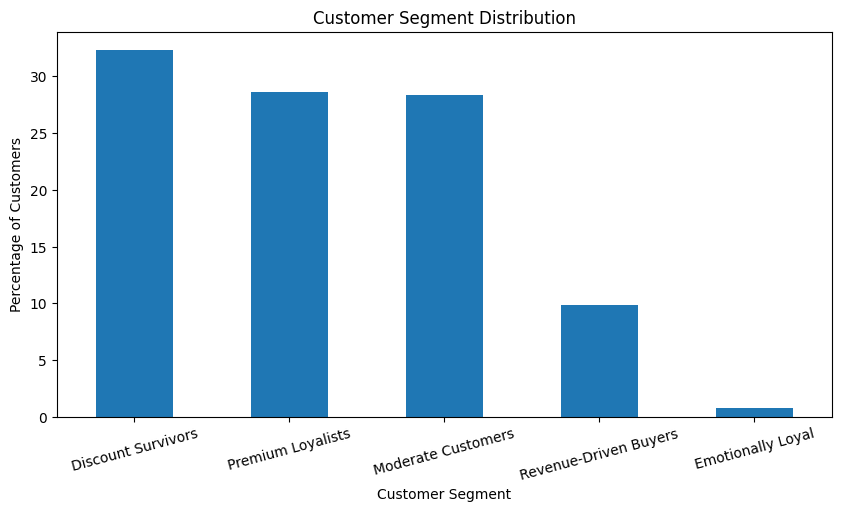

In [34]:
# Segment Distribution Visualization

segment_percentage.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Percentage of Customers")

plt.xticks(rotation=15)

plt.show()

## Promo Dependency Business Validation

### Objective
Evaluate whether promotional dependency is artificially influencing customer value and loyalty perception.

### Strategic Question
Are high-spending customers genuinely loyal, or are they heavily promotion-driven?

In [35]:
# Promo Dependency by Segment

promo_analysis = df.groupby(
    "Master_Customer_Segment"
)[
    "Promo_Dependency_Score"
].mean().round(2)

promo_analysis

,Promo_Dependency_Score
Master_Customer_Segment,
Discount Survivors,1.0
Emotionally Loyal,1.0
Moderate Customers,0.0
Premium Loyalists,0.0
Revenue-Driven Buyers,1.0


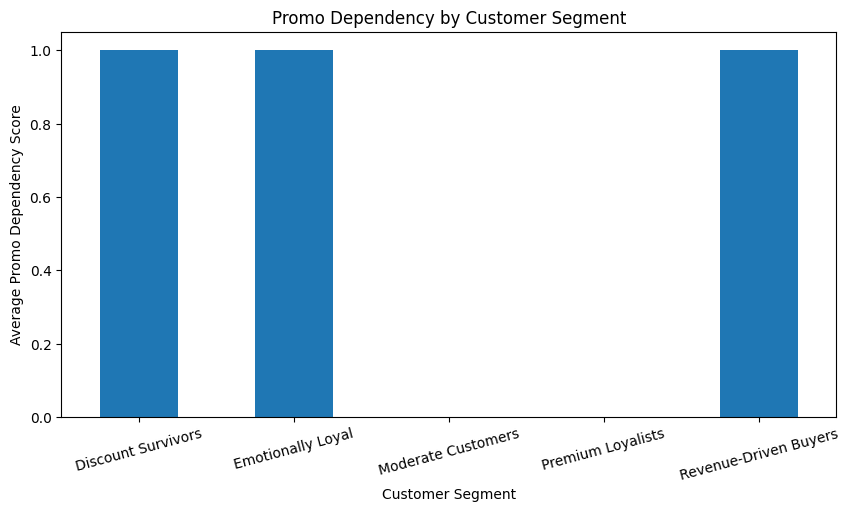

In [36]:
# Promo Dependency Visualization

promo_analysis.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Promo Dependency by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Promo Dependency Score")

plt.xticks(rotation=15)

plt.show()

## Loyalty vs Revenue Validation

### Objective
Compare behavioral loyalty and commercial loyalty to identify strategic customer differences.

### Strategic Importance
Helps determine whether:
- spending behavior
- engagement behavior
- promo dependency

are aligned or conflicting.

In [37]:
# Loyalty Comparison Summary

loyalty_validation = df.groupby(
    "Master_Customer_Segment"
)[[
    "Loyalty_Score_A",
    "Loyalty_Score_B"
]].mean().round(2)

loyalty_validation

,Loyalty_Score_A,Loyalty_Score_B
Master_Customer_Segment,,
Discount Survivors,0.46,0.47
Emotionally Loyal,0.73,0.63
Moderate Customers,0.59,0.43
Premium Loyalists,0.81,0.67
Revenue-Driven Buyers,0.63,0.81


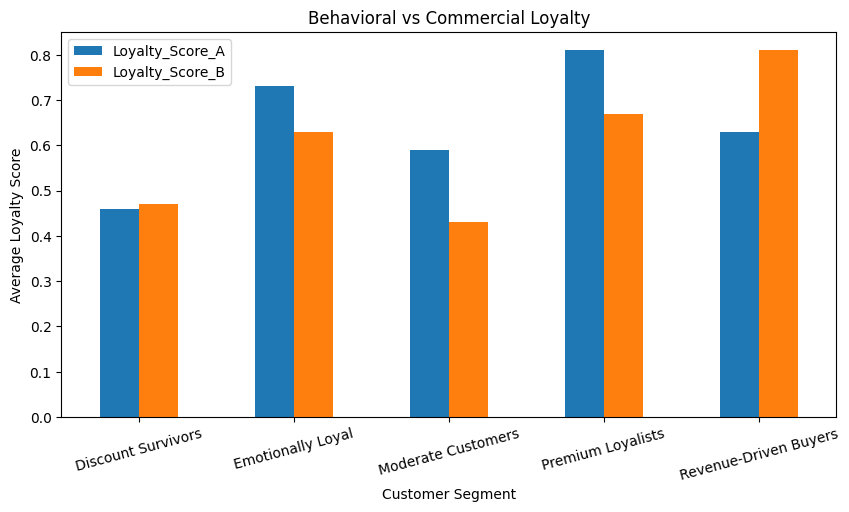

In [38]:
# Loyalty Comparison Visualization

loyalty_validation.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Behavioral vs Commercial Loyalty")
plt.xlabel("Customer Segment")
plt.ylabel("Average Loyalty Score")

plt.xticks(rotation=15)

plt.show()

## Customer Value Validation

### Objective
Evaluate which customer segments contribute the strongest commercial value.

### Strategic Importance
Supports:
- retention investment decisions
- premium customer targeting
- customer prioritization strategy

In [39]:
# Average Purchase Value by Segment

value_analysis = df.groupby(
    "Master_Customer_Segment"
)[
    "Purchase Amount (USD)"
].mean().round(2)

value_analysis

,Purchase Amount (USD)
Master_Customer_Segment,
Discount Survivors,53.57
Emotionally Loyal,33.34
Moderate Customers,59.61
Premium Loyalists,60.65
Revenue-Driven Buyers,80.11


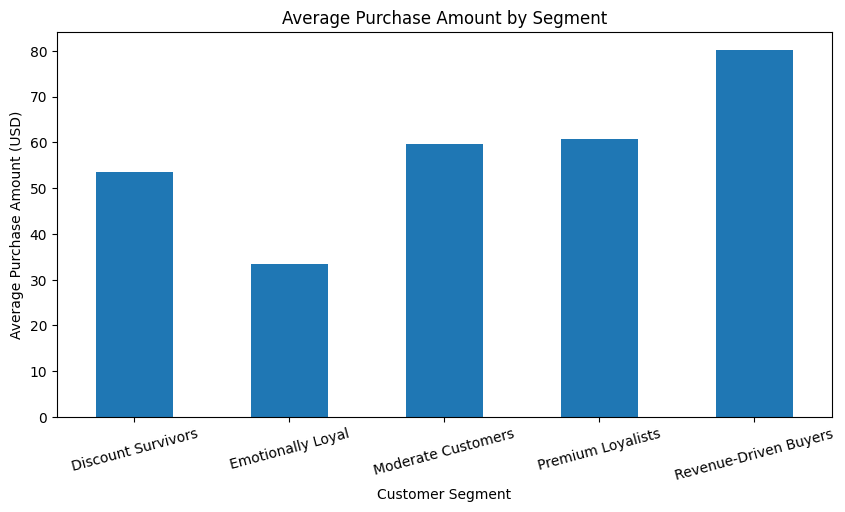

In [40]:
# Customer Value Visualization

value_analysis.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Average Purchase Amount by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Purchase Amount (USD)")

plt.xticks(rotation=15)

plt.show()

# Founder-Level Strategic Insights

The following insights summarize key retention and customer intelligence findings derived from the analysis.

In [41]:
# Founder-Level Insights

founder_insights = [

    "Premium Loyalists appear to generate sustainable long-term customer value with lower promotional dependency.",

    "Revenue-Driven Buyers contribute strong commercial value but may rely more heavily on promotions.",

    "Discount Survivors may create short-term revenue while weakening long-term profitability.",

    "Behavioral loyalty and commercial loyalty do not always align.",

    "Retention strategies should differentiate between emotionally loyal customers and promotion-driven buyers.",

    "Reducing unnecessary discount exposure may improve margin quality without significantly harming genuinely loyal customers."
]

for insight in founder_insights:
    print("•", insight)

• Premium Loyalists appear to generate sustainable long-term customer value with lower promotional dependency.
• Revenue-Driven Buyers contribute strong commercial value but may rely more heavily on promotions.
• Discount Survivors may create short-term revenue while weakening long-term profitability.
• Behavioral loyalty and commercial loyalty do not always align.
• Retention strategies should differentiate between emotionally loyal customers and promotion-driven buyers.
• Reducing unnecessary discount exposure may improve margin quality without significantly harming genuinely loyal customers.


# Retention Strategy Recommendations

The following recommendations are designed to support:
- sustainable retention
- customer quality optimization
- promotional efficiency
- long-term customer value growth

In [42]:
# Strategic Recommendations

recommendations = [

    "Prioritize retention investments toward Premium Loyalists and highly engaged customers.",

    "Reduce blanket discounting for heavily promo-dependent segments.",

    "Design differentiated engagement strategies for emotionally loyal customers.",

    "Use promotional campaigns more selectively for margin protection.",

    "Develop upsell strategies for moderate-value but highly engaged customers.",

    "Monitor promo dependency closely to avoid artificial revenue inflation."
]

for recommendation in recommendations:
    print("•", recommendation)

• Prioritize retention investments toward Premium Loyalists and highly engaged customers.
• Reduce blanket discounting for heavily promo-dependent segments.
• Design differentiated engagement strategies for emotionally loyal customers.
• Use promotional campaigns more selectively for margin protection.
• Develop upsell strategies for moderate-value but highly engaged customers.
• Monitor promo dependency closely to avoid artificial revenue inflation.


# Final Conclusion

This project focused on building an AI-assisted customer intelligence and retention strategy system for a D2C fashion brand.

The analysis moved beyond basic dashboarding and explored:
- customer loyalty behavior
- promotional dependency
- customer segmentation
- retention intelligence
- founder-oriented strategic decision-making

Key outcomes:
- Developed behavioral and commercial loyalty frameworks
- Identified promo-dependent customer segments
- Built customer intelligence segmentation logic
- Generated retention-oriented strategic recommendations
- Created a foundation for dashboard storytelling and business decision support

The project demonstrates how analytics can be transformed into commercially meaningful customer intelligence instead of shallow reporting.

# Strategic Metric Refinement

Following strategic review and validation, several metric names were refined to improve analytical precision and business realism.

The objective of these refinements was to:
- reduce misleading terminology
- improve retention analytics credibility
- align terminology with product analytics standards
- strengthen portfolio realism

In [43]:
# Strategic Metric Renaming

df.rename(columns={

    "Review_Engagement_Score":
    "Review_Satisfaction_Score",

    "Purchase_Frequency_Score":
    "Purchase_Intensity_Score"

}, inplace=True)

print("Metric names refined successfully.")

Metric names refined successfully.
